# Calibration

**This notebook assesses calibration performance of the gradient boosted survival model and recalibrates predictions using isotonic regression.**

In [1]:
import sys
sys.path.append('../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from scipy.stats import linregress
from sklearn.model_selection import StratifiedKFold
from joblib import Parallel, delayed
from sklearn.isotonic import IsotonicRegression
from sksurv.metrics import brier_score

from utils.calibration import calculate_calibration_curve, calibrate_survival_predictions

## Import Data

In [2]:
survival_predictions_df = pd.read_csv('../../mRCC/outputs/gb_survival_predictions.csv')

In [3]:
survival_predictions_df = survival_predictions_df[['PatientID', 'risk_score', 'psurv_180', 'psurv_365']]

In [4]:
survival_predictions_df.shape

(8291, 4)

In [5]:
dtype_map = pd.read_csv('../outputs/ioio_tki_features_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
iotki_ioio_df = pd.read_csv('../outputs/ioio_tki_features.csv', dtype = dtype_map)

In [6]:
iotki_ioio_df.shape

(4366, 161)

In [7]:
df = pd.merge(iotki_ioio_df, survival_predictions_df, on = 'PatientID', how = 'left')

In [8]:
df.shape

(4366, 164)

In [9]:
df = df.query('met_diagnosis_year <= 2020')

In [10]:
df.shape

(4193, 164)

## Raw Calibration Assessment

In [11]:
cal_df = calculate_calibration_curve(df, 'psurv_180', 180)

In [12]:
cal_df

,bin,predicted,observed,n,obs_lo,obs_hi
0,"(-0.00093, 0.605]",0.433503,0.394787,420,0.346272,0.441592
1,"(0.605, 0.72]",0.671887,0.657399,419,0.609102,0.701241
2,"(0.72, 0.777]",0.749711,0.714704,419,0.667834,0.756196
3,"(0.777, 0.815]",0.797208,0.824386,419,0.783616,0.858175
4,"(0.815, 0.847]",0.832121,0.836755,420,0.797277,0.869181
5,"(0.847, 0.872]",0.860000,0.869385,419,0.830337,0.896840
6,"(0.872, 0.889]",0.880603,0.909250,419,0.876920,0.933409
7,"(0.889, 0.905]",0.896882,0.946134,419,0.917248,0.962769
8,"(0.905, 0.922]",0.913417,0.958734,419,0.932377,0.972796
9,"(0.922, 0.962]",0.935567,0.975885,420,0.955175,0.986685


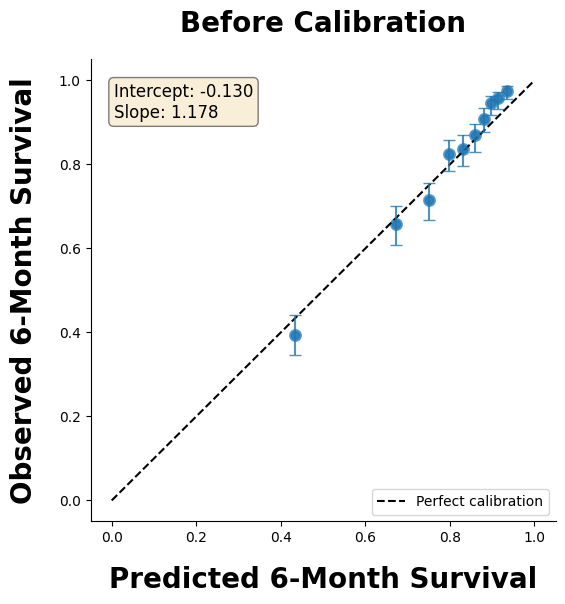

In [13]:
slope_orig, intercept_orig, _, _, _ = linregress(
    cal_df['predicted'], 
    cal_df['observed']
)

# Plot
plt.figure(figsize = (6, 6))
plt.scatter(cal_df['predicted'], cal_df['observed'], s = 70, alpha = 0.6)
plt.plot([0, 1], [0, 1], 'k--', label = 'Perfect calibration')

# Error bar 
yerr = np.vstack([
    cal_df['observed'] - cal_df['obs_lo'],
    cal_df['obs_hi'] - cal_df['observed']
])

plt.errorbar(
    cal_df['predicted'],
    cal_df['observed'],
    yerr = yerr,
    fmt = 'o',           
    elinewidth = 1.5,    
    capsize = 4,         
    alpha = 0.8
)

# Add text box with calibration metrics
textstr = f'Intercept: {intercept_orig:.3f}\nSlope: {slope_orig:.3f}'
plt.text(0.05, 0.95, textstr, transform = plt.gca().transAxes, 
         fontsize = 12, verticalalignment = 'top',
         bbox = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5))

plt.xlabel('Predicted 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.ylabel('Observed 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.title('Before Calibration',  weight = 'bold', size = 20, pad = 20)
plt.legend()

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig('../outputs/uncalibrated_gb_6m_survival_prediction_plot.pdf', format = 'pdf', bbox_inches = 'tight')

plt.show()

## Isotonic Calibration Using Cross Validation 

In [14]:
# Prepare structured array for survival outcomes
y_dtype = [('event', bool), ('duration', float)]

y = np.array([tuple(x) for x in df[['event', 'duration']].values],
             dtype = y_dtype)

In [15]:
df, brier_scores = calibrate_survival_predictions(df, y, 'psurv_180', 180)


=== Fold 1/5 ===
Brier score at 180 days (calibrated): 0.1311

=== Fold 2/5 ===
Brier score at 180 days (calibrated): 0.1277

=== Fold 3/5 ===
Brier score at 180 days (calibrated): 0.1317

=== Fold 4/5 ===
Brier score at 180 days (calibrated): 0.1211

=== Fold 5/5 ===
Brier score at 180 days (calibrated): 0.1109

=== Summary ===
psurv_180_calibrated computed: 4193

=== Brier Scores at 180 days (calibrated) ===
Mean: 0.1245 ± 0.0078


In [16]:
df_final_calibrated = df[['PatientID', 'psurv_180_calibrated']]

In [17]:
df_final_calibrated.to_csv('../outputs/gb_6m_survival_predictions_calibrated.csv', index = False)

In [18]:
cal_iso_df = calculate_calibration_curve(df, 'psurv_180_calibrated', 180)

In [19]:
cal_iso_df

,bin,predicted,observed,n,obs_lo,obs_hi
0,"(-0.001, 0.552]",0.395500,0.395967,424,0.347680,0.442550
1,"(0.552, 0.697]",0.651325,0.673213,418,0.622951,0.714338
2,"(0.697, 0.786]",0.728214,0.721685,428,0.675670,0.762346
3,"(0.786, 0.821]",0.809114,0.812722,428,0.771504,0.847249
4,"(0.821, 0.868]",0.847082,0.846502,428,0.808149,0.877771
5,"(0.868, 0.894]",0.880197,0.872405,443,0.836199,0.899833
6,"(0.894, 0.942]",0.914753,0.915580,389,0.882721,0.939548
7,"(0.942, 0.952]",0.948285,0.948313,475,0.922032,0.963783
8,"(0.952, 0.966]",0.960734,0.951228,376,0.923109,0.968600
9,"(0.966, 1.0]",0.984211,0.968412,384,0.944544,0.981636


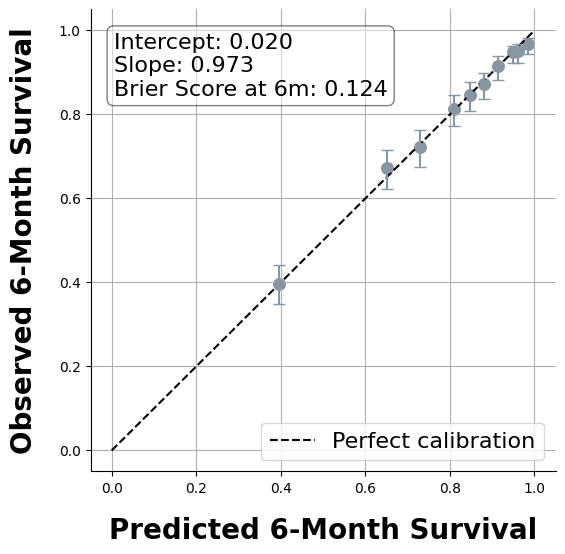

In [20]:
slope_iso, intercept_iso, _, _, _ = linregress(
    cal_iso_df['predicted'], 
    cal_iso_df['observed']
)

# Plot
plt.figure(figsize = (6, 6))
plt.scatter(cal_iso_df['predicted'], cal_iso_df['observed'], s = 70, color='#8896A4')
plt.plot([0, 1], [0, 1], 'k--', label = 'Perfect calibration')

# Error bar 
yerr = np.vstack([
    cal_iso_df['observed'] - cal_iso_df['obs_lo'],
    cal_iso_df['obs_hi'] - cal_iso_df['observed']
])

plt.errorbar(
    cal_iso_df['predicted'],
    cal_iso_df['observed'],
    yerr = yerr,
    fmt = 'o',           
    elinewidth = 1.5,
    color='#8896A4',
    capsize = 4
)

# Add text box with calibration metrics
textstr = f'Intercept: {intercept_iso:.3f}\nSlope: {slope_iso:.3f}\nBrier Score at 6m: {np.mean(brier_scores):.3f}'
plt.text(0.05, 0.95, textstr, transform = plt.gca().transAxes, 
         fontsize = 16, verticalalignment = 'top',
         bbox = dict(boxstyle = 'round', facecolor = 'white', alpha = 0.5))

plt.xlabel('Predicted 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.ylabel('Observed 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
#plt.title('After Isotonic Calibration',  weight = 'bold', size = 20, pad = 20)
plt.legend(fontsize=16)
plt.grid(True)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig('../outputs/calibrated_gb_6m_survival_prediction_plot.pdf', format = 'pdf', bbox_inches = 'tight')

plt.show()